# Single tx dataset

In [46]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

## Test runs

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [2]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.SINGLE,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "deepsad,ablationsemfusion",

    "num_epochs": 100,
    "learning_rate": 0.005,
    "augment_factor": 0,
    "dme_threshold": 0.5,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
    "rep_dim": 64,
    "eta": 1.0,
    "deep_sad_eps": 1.0,
    "grad_clip": 1.0,
    "weight_decay": 1e-6,
    "ae_pretrain": False,
}

In [4]:
# Run without semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=False
))

Early stopping: 15
Exporting data from database to CSV files... 


Processing single-chain graphs dataset: 100%|██████████| 1152/1152 [00:14<00:00, 78.60graph/s]


Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 264 differential meta-paths for training.
Fold 1: centre initialised from 625 normal graphs.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 1.5176, val loss: 0.1747, PR-AUC (anomaly): 0.7555, f2-score (anomaly): 0.8373, tau: 1.2513e-01
  dist(normal) 1.0167e-01+-1.7177e-01 | dist(anomaly) 5.2253e+01+-8.4283e+01
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       157
           1       0.66      0.90      0.76        39

    accuracy                           0.89       196
   macro avg       0.82      0.89      0.84       196
weighted avg       0.91      0.89      0.89       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.3731, val loss: 0.1792, PR-AUC (anomaly): 0.52

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_deepsad_ablationsemfusion__202608171052'

In [5]:
# Run with semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=True
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 264 differential meta-paths for training.
Fold 1: centre initialised from 625 normal graphs.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 2.5064, val loss: 0.2811, PR-AUC (anomaly): 0.7621, f2-score (anomaly): 0.8374, tau: 4.1361e-01
  dist(normal) 2.5503e-01+-4.4121e-01 | dist(anomaly) 6.1730e+01+-1.1006e+02
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       157
           1       0.72      0.87      0.79        39

    accuracy                           0.91       196
   macro avg       0.84      0.89      0.87       196
weighted avg       0.92      0.91      0.91       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoc

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_deepsad_ablationsemfusion__202608171100'

## Results processing

In [47]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.005*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 2 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_deepsad_ablationsemfusion__202608171052
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_deepsad_ablationsemfusion__202608171100


In [48]:
import yaml
import pandas as pd

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "rm_semantic_fusion": doc["params"].get("rm_semantic_fusion", False),
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

def load_val_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "val_best_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }


configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)

metrics = [load_val_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)

comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["rm_semantic_fusion"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,rm_semantic_fusion,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,epoch_mean,epoch_std,val_loss_mean,...,threshold_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_es15_deepsad_...,False,264,0.040772,1152,0.2014,22.4,7.059745,3.776713,...,0.052767,0.919368,0.019672,0.948976,0.023007,0.932476,0.018021,95.002,14.103670,475.01
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_nosf_es15_dee...,True,264,0.040772,1152,0.2014,18.6,14.650597,0.429006,...,1.048105,0.901635,0.045324,0.951411,0.025355,0.920389,0.037880,73.300,23.843677,366.50


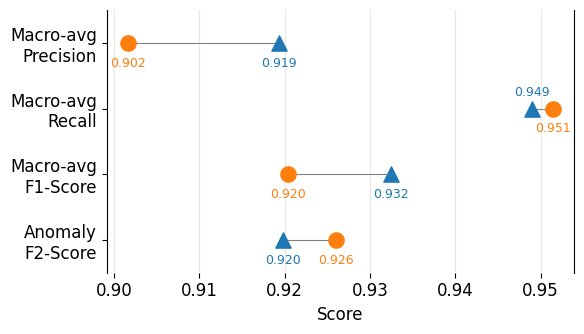

In [53]:
import numpy as np

# Cleveland dot plot: metrics on y, score on x; one colored dot per evaluation
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plot_df = comparison_df.copy()
plot_df["evaluation"] = plot_df["rm_semantic_fusion"].map({False: "With Semantic Fusion", True: "Without Semantic Fusion"})
evals = plot_df["evaluation"].tolist()
metric_cols = [
    "precision_macro_mean",
    "recall_macro_mean",
    "f1_macro_mean",
    "f2_anomaly_mean"
]
y = np.arange(len(metric_cols))
labels = [
    "Macro-avg\nPrecision",
    "Macro-avg\nRecall",
    "Macro-avg\nF1-Score",
    "Anomaly\nF2-Score"
]

plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(6, 3.5))

# map evaluations to distinct colors
unique_evals = plot_df["evaluation"].unique().tolist()
cmap = plt.get_cmap("tab10")
color_map = {ev: cmap(i) for i, ev in enumerate(unique_evals)}
marker_map = {ev: "^" if ev == unique_evals[0] else "o" for ev in unique_evals}

# draw grey connector lines for each metric
for i in range(len(metric_cols)):
    vals = plot_df[metric_cols].iloc[:, i] if False else plot_df[metric_cols].iloc[:, i]  # noop for clarity
for i in range(len(metric_cols)):
    # values for this metric across evaluations (respect row order)
    vals = plot_df[metric_cols].iloc[:, i].to_numpy()  # not used; keep loop for connector below

# connector and points (use the row order in plot_df)
for i, metric in enumerate(metric_cols):
    vals = plot_df[metric].to_numpy(dtype=float)
    ax.plot(vals, [i, i], color="gray", linewidth=0.8, zorder=1)
for j, ev_name in enumerate(evals):
    row = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0]
    for i, metric in enumerate(metric_cols):
        ax.annotate(
            f"{row[metric]:.3f}",
            (row[metric], i),
            textcoords="offset points",
            xytext=(0, 16) if j == 0 and abs(plot_df[metric].iloc[0] - plot_df[metric].iloc[1]) < 0.004 else (0, -10),
            ha="center",
            va="top",
            fontsize=9,
            color=color_map[ev_name],
        )
    vals = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0].to_numpy(dtype=float)
    ax.scatter(vals, y, s=120, color=color_map[ev_name], label=ev_name, zorder=2, marker=marker_map[ev_name])

ax.set_yticks(y)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylim(y.min() - 0.5, y.max() + 0.5)

ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Score")
ax.grid(axis="x", alpha=0.3)
# set x limits with a small margin
all_vals = plot_df[metric_cols].to_numpy(dtype=float)
xmin, xmax = all_vals.min(), all_vals.max()
pad = (xmax - xmin) * 0.05 if xmax > xmin else 0.01
ax.set_xlim(xmin - pad, xmax + pad)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.01))
#ax.legend() # UNCOMMENT THIS LINE TO CHECK IF LEGEND IS CORRECT WITH THE MARKERS
plt.tight_layout()

plt.show()

In [51]:
trimmed_df = comparison_df[[
    "rm_semantic_fusion",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,rm_semantic_fusion,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,f1_normal_std,precision_anomaly_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,False,0.955055,0.011817,0.984428,0.011881,0.959105,0.012455,0.971506,0.007471,0.854308,...,0.938846,0.047712,0.893446,0.028679,0.919840,0.037040,0.923277,0.019498,95.002,14.103670
1,True,0.943841,0.030417,0.990876,0.011689,0.938592,0.040656,0.963453,0.020872,0.812394,...,0.964231,0.047585,0.877325,0.055075,0.926058,0.038305,0.907299,0.074084,73.300,23.843677


In [52]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "Semantic Fusion", (trimmed_df["rm_semantic_fusion"].map({False: "Included", True: "Not Included"})))
display_df = display_df.set_index("Semantic Fusion")

final_table = display_df.T
final_table

Semantic Fusion,Included,Not Included
accuracy,95.51 ± 01.18,94.38 ± 03.04
precision_normal,98.44 ± 01.19,99.09 ± 01.17
recall_normal,95.91 ± 01.25,93.86 ± 04.07
f1_normal,97.15 ± 00.75,96.35 ± 02.09
precision_anomaly,85.43 ± 03.86,81.24 ± 09.37
recall_anomaly,93.88 ± 04.77,96.42 ± 04.76
f1_anomaly,89.34 ± 02.87,87.73 ± 05.51
f2_anomaly,91.98 ± 03.70,92.61 ± 03.83
pr_auc,92.33 ± 01.95,90.73 ± 07.41
fold_time,95.00 ± 14.10,73.30 ± 23.84


In [38]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "Semantic Fusion": "Semantic Fusion",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:ablation_semantic_fusion",
)
print(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:ablation_semantic_fusion}
\begin{tabular}{lcc}
\toprule
Semantic Fusion & Included & Not Included \\
\midrule
Accuracy (\%) & $95.51 \pm 01.18$ & $94.38 \pm 03.04$ \\
Precision (Normal) (\%) & $98.44 \pm 01.19$ & $99.09 \pm 01.17$ \\
Recall (Normal) (\%) & $95.91 \pm 01.25$ & $93.86 \pm 04.07$ \\
F1 (Normal) (\%) & $97.15 \pm 00.75$ & $96.35 \pm 02.09$ \\
Precision (Anomaly) (\%) & $85.43 \pm 03.86$ & $81.24 \pm 09.37$ \\
Recall (Anomaly) (\%) & $93.88 \pm 04.77$ & $96.42 \pm 04.76$ \\
F1 (Anomaly) (\%) & $89.34 \pm 02.87$ & $87.73 \pm 05.51$ \\
F2 (Anomaly) (\%) & $91.98 \pm 03.70$ & $92.61 \pm 03.83$ \\
PR-AUC (\%) & $92.33 \pm 01.95$ & $90.73 \pm 07.41$ \\
Fold Training Time (sec/fold) & $95.00 \pm 14.10$ & $73.30 \pm 23.84$ \\
\bottomrule
\end{tabular}
\end{table}



# Cross-chain tx scope

In [54]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

## Test runs

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [2]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.CCTX,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "deepsad,ablationsemfusion",

    "num_epochs": 100,
    "learning_rate": 0.002, # Notice that for the new approach in cctx scope, lr is smaller
    "augment_factor": 0,
    "dme_threshold": 0.5,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
    "rep_dim": 64,
    "eta": 1.0,
    "deep_sad_eps": 1.0,
    "grad_clip": 1.0,
    "weight_decay": 1e-6,
    "ae_pretrain": False,
}

In [4]:
# Run with semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=False
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 499 differential meta-paths for training.
Fold 1: centre initialised from 786 normal graphs.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 0.8557, val loss: 0.2158, PR-AUC (anomaly): 0.0437, f2-score (anomaly): 0.2881, tau: 4.8150e-02
  dist(normal) 1.6586e-01+-3.6352e-01 | dist(anomaly) 5.5607e-02+-9.7469e-03
              precision    recall  f1-score   support

           0       1.00      0.12      0.22       197
           1       0.07      1.00      0.14        14

    accuracy                           0.18       211
   macro avg       0.54      0.56      0.18       211
weighted avg       0.94      0.18      0.21       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.2651, val loss: 0.1178, PR-A

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_es15_deepsad_ablationsemfusion__202608171445'

In [ ]:
# Run without semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=True
))

## Results processing

In [55]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.002*")
    if p.is_dir() and (p / "params.yaml").exists()
)
print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 2 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_es15_deepsad_ablationsemfusion__202608171445
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_nosf_es15_deepsad_ablationsemfusion__202608171107


In [56]:
import yaml
import pandas as pd

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "rm_semantic_fusion": doc["params"]["rm_semantic_fusion"] if "rm_semantic_fusion" in doc["params"] else False,
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

def load_val_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "val_best_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }


configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)

metrics = [load_val_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)

comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["rm_semantic_fusion"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,rm_semantic_fusion,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,epoch_mean,epoch_std,val_loss_mean,...,threshold_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_es15_deepsad_...,False,499,0.077066,1241,0.0677,17.8,9.537295,0.076343,...,48.874881,0.99848,0.001241,0.979048,0.01713,0.988382,0.009497,242.518,39.701829,1212.59
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_nosf_es15_dee...,True,499,0.077066,1241,0.0677,20.0,7.402702,0.032218,...,0.674111,0.99848,0.001241,0.979048,0.01713,0.988382,0.009497,218.612,45.701673,1093.06


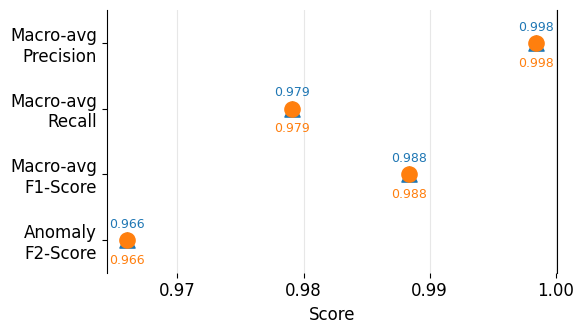

In [57]:
import numpy as np

# Cleveland dot plot: metrics on y, score on x; one colored dot per evaluation
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plot_df = comparison_df.copy()
plot_df["evaluation"] = plot_df["rm_semantic_fusion"].map({False: "With Semantic Fusion", True: "Without Semantic Fusion"})
evals = plot_df["evaluation"].tolist()
metric_cols = [
    "precision_macro_mean",
    "recall_macro_mean",
    "f1_macro_mean",
    "f2_anomaly_mean"
]
y = np.arange(len(metric_cols))
labels = [
    "Macro-avg\nPrecision",
    "Macro-avg\nRecall",
    "Macro-avg\nF1-Score",
    "Anomaly\nF2-Score"
]

plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(6, 3.5))

# map evaluations to distinct colors
unique_evals = plot_df["evaluation"].unique().tolist()
cmap = plt.get_cmap("tab10")
color_map = {ev: cmap(i) for i, ev in enumerate(unique_evals)}
marker_map = {ev: "^" if ev == unique_evals[0] else "o" for ev in unique_evals}

# draw grey connector lines for each metric
for i in range(len(metric_cols)):
    vals = plot_df[metric_cols].iloc[:, i] if False else plot_df[metric_cols].iloc[:, i]  # noop for clarity
for i in range(len(metric_cols)):
    # values for this metric across evaluations (respect row order)
    vals = plot_df[metric_cols].iloc[:, i].to_numpy()  # not used; keep loop for connector below

# connector and points (use the row order in plot_df)
for i, metric in enumerate(metric_cols):
    vals = plot_df[metric].to_numpy(dtype=float)
    ax.plot(vals, [i, i], color="gray", linewidth=0.8, zorder=1)
for j, ev_name in enumerate(evals):
    row = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0]
    for i, metric in enumerate(metric_cols):
        ax.annotate(
            f"{row[metric]:.3f}",
            (row[metric], i),
            textcoords="offset points",
            xytext=(0, 16) if j == 0 and abs(plot_df[metric].iloc[0] - plot_df[metric].iloc[1]) < 0.004 else (0, -10),
            ha="center",
            va="top",
            fontsize=9,
            color=color_map[ev_name],
        )
    vals = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0].to_numpy(dtype=float)
    ax.scatter(vals, y, s=120, color=color_map[ev_name], label=ev_name, zorder=2, marker=marker_map[ev_name])

ax.set_yticks(y)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylim(y.min() - 0.5, y.max() + 0.5)

ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Score")
ax.grid(axis="x", alpha=0.3)
# set x limits with a small margin
all_vals = plot_df[metric_cols].to_numpy(dtype=float)
xmin, xmax = all_vals.min(), all_vals.max()
pad = (xmax - xmin) * 0.05 if xmax > xmin else 0.01
ax.set_xlim(xmin - pad, xmax + pad)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.01))
#ax.legend() # UNCOMMENT THIS LINE TO CHECK IF LEGEND IS CORRECT WITH THE MARKERS
plt.tight_layout()

plt.show()

In [43]:
trimmed_df = comparison_df[[
    "rm_semantic_fusion",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,rm_semantic_fusion,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,f1_normal_std,precision_anomaly_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,False,0.997152,0.002325,0.996959,0.002483,1.0,0.0,0.998476,0.001244,1.0,...,0.958095,0.034259,0.978289,0.017752,0.966001,0.027797,0.977839,0.020419,242.518,39.701829
1,True,0.997152,0.002325,0.996959,0.002483,1.0,0.0,0.998476,0.001244,1.0,...,0.958095,0.034259,0.978289,0.017752,0.966001,0.027797,0.967798,0.027153,218.612,45.701673


In [44]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "Semantic Fusion", (trimmed_df["rm_semantic_fusion"].map({False: "Included", True: "Not Included"})))
display_df = display_df.set_index("Semantic Fusion")

final_table = display_df.T
final_table

Semantic Fusion,Included,Not Included
accuracy,99.72 ± 00.23,99.72 ± 00.23
precision_normal,99.70 ± 00.25,99.70 ± 00.25
recall_normal,100.00 ± 00.00,100.00 ± 00.00
f1_normal,99.85 ± 00.12,99.85 ± 00.12
precision_anomaly,100.00 ± 00.00,100.00 ± 00.00
recall_anomaly,95.81 ± 03.43,95.81 ± 03.43
f1_anomaly,97.83 ± 01.78,97.83 ± 01.78
f2_anomaly,96.60 ± 02.78,96.60 ± 02.78
pr_auc,97.78 ± 02.04,96.78 ± 02.72
fold_time,242.52 ± 39.70,218.61 ± 45.70


In [45]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "Semantic Fusion": "Semantic Fusion",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:ablation_semantic_fusion",
)
print(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:ablation_semantic_fusion}
\begin{tabular}{lcc}
\toprule
Semantic Fusion & Included & Not Included \\
\midrule
Accuracy (\%) & $99.72 \pm 00.23$ & $99.72 \pm 00.23$ \\
Precision (Normal) (\%) & $99.70 \pm 00.25$ & $99.70 \pm 00.25$ \\
Recall (Normal) (\%) & $100.00 \pm 00.00$ & $100.00 \pm 00.00$ \\
F1 (Normal) (\%) & $99.85 \pm 00.12$ & $99.85 \pm 00.12$ \\
Precision (Anomaly) (\%) & $100.00 \pm 00.00$ & $100.00 \pm 00.00$ \\
Recall (Anomaly) (\%) & $95.81 \pm 03.43$ & $95.81 \pm 03.43$ \\
F1 (Anomaly) (\%) & $97.83 \pm 01.78$ & $97.83 \pm 01.78$ \\
F2 (Anomaly) (\%) & $96.60 \pm 02.78$ & $96.60 \pm 02.78$ \\
PR-AUC (\%) & $97.78 \pm 02.04$ & $96.78 \pm 02.72$ \\
Fold Training Time (sec/fold) & $242.52 \pm 39.70$ & $218.61 \pm 45.70$ \\
\bottomrule
\end{tabular}
\end{table}

